In [11]:
import pandas as pd

In [2]:
results = pd.read_csv("/projects/ataghinia@xsede.org/PAVE-Pathology/eval_results/EVAL_end_to_end/results.csv")

OR

In [2]:
results = pd.read_csv("/projects/ataghinia@xsede.org/PAVE-Pathology/eval_results/EVAL_end_to_end_aug/results.csv")

OR

In [37]:
results = pd.read_csv("/projects/ataghinia@xsede.org/PAVE-Pathology/eval_results/EVAL_end_to_end_FLAGSHIP/results.csv")

In [38]:
# Assign final prediction label based on suff_pred, norm_pred, and priority_pred
def get_final_pred(row):
    if row['suff_pred'] == 0:
        return 'insufficient'
    elif row['norm_pred'] == 0:
        return 'normal'
    else:
        # abnormal, so use priority_pred
        return {0: 'low_grade', 1: 'high_grade', 2: 'cancer'}.get(row['priority_pred'], 'unknown')

In [39]:
# Define the order of labels for rows and columns
class_labels = ['insufficient', 'normal', 'low_grade', 'high_grade', 'cancer']

results['pred'] = pd.Categorical(
    results.apply(get_final_pred, axis=1), 
    categories=class_labels,
    ordered=True
)

results['label'] = pd.Categorical(
    results['label'], 
    categories=class_labels,
    ordered=True
)

In [40]:
results.pred.value_counts()

pred
normal          158
low_grade       144
high_grade      138
insufficient     87
cancer           10
Name: count, dtype: int64

In [44]:
patient_lvl = results.groupby('case_id')['pred'].agg(pred='max')
patient_lvl['label'] = results.groupby('case_id')['label'].agg('max')

In [46]:
patient_lvl.pred.value_counts()

pred
high_grade      105
low_grade        99
normal           60
insufficient     18
cancer            5
Name: count, dtype: int64

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def cm(gt, pred, labels):
# Generate confusion matrix between 'label' and 'pred' columns
    cm = confusion_matrix(gt, pred, labels=labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels,
                yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Rotate x-axis labels if they're long
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

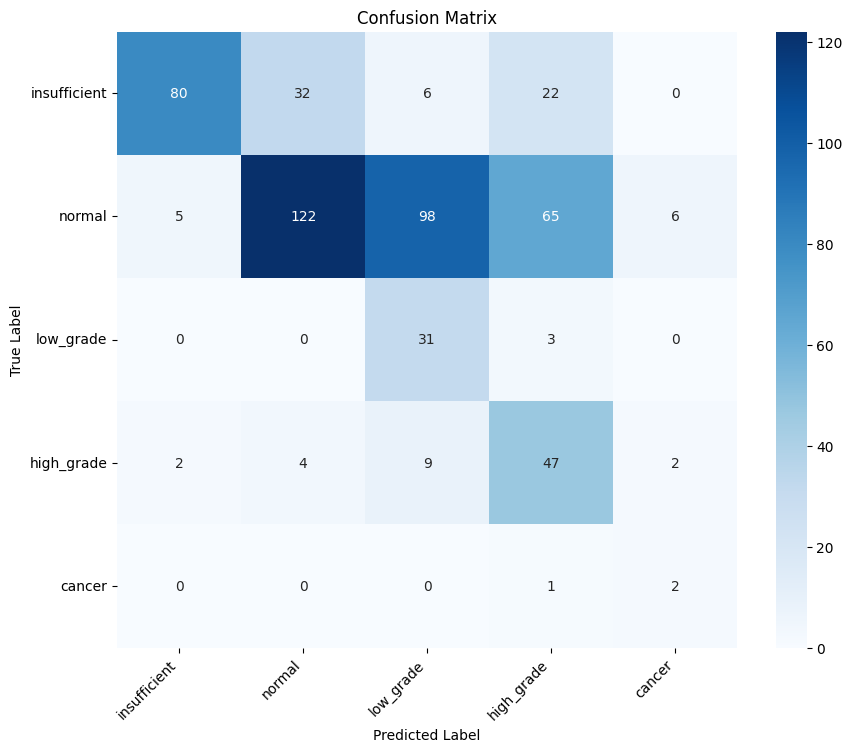

In [49]:
cm(results.label, results.pred, class_labels)

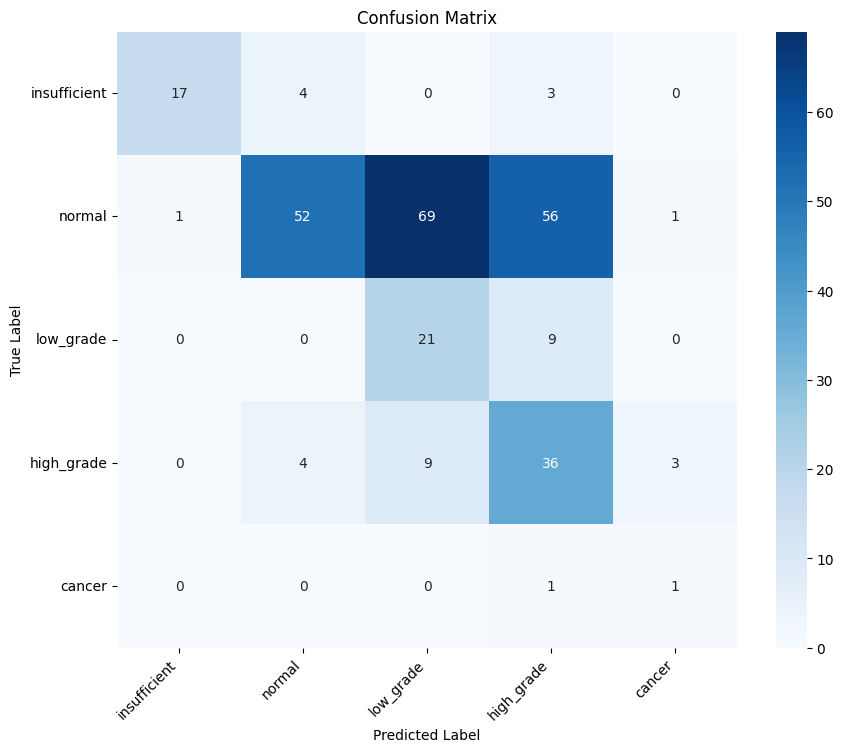

In [50]:
cm(patient_lvl.label, patient_lvl.pred, class_labels)

### Full Model w/ Logit Scaling Patient LVL

In [10]:
import pandas as pd

In [47]:
results = pd.read_csv("/projects/ataghinia@xsede.org/PAVE-Pathology/eval_results/EVAL_full_subtyping_patient_adjusted/fold_0.csv")

In [48]:
labels = pd.read_csv("/projects/ataghinia@xsede.org/PAVE-Pathology/dataset_csv/pathology_full_subtyping.csv")

In [49]:
results = pd.merge(results, labels[['slide_id','case_id']], on='slide_id')

In [50]:
results.head()

,slide_id,Y,Y_hat,p_0,p_1,p_2,p_3,p_4,case_id
0,PATH000009462,1.0,1.0,0.006575,0.658396,0.079817,0.255210,0.000003,02-00168
1,PATH000009869,0.0,0.0,0.467735,0.207200,0.124183,0.200818,0.000065,02-00520
2,PATH000009514,0.0,3.0,0.228963,0.346735,0.060410,0.363720,0.000172,02-00546
3,PATH000009940,1.0,2.0,0.010353,0.163166,0.662774,0.163665,0.000042,02-00902
4,PATH000009837,1.0,2.0,0.010238,0.449292,0.492675,0.047791,0.000004,02-00938


In [51]:
patient_lvl = results.groupby('case_id')['Y_hat'].agg(pred='max')
patient_lvl['label'] = results.groupby('case_id')['Y'].agg('max')

mapping = {
    0.0: 'insufficient',
    1.0: 'normal',
    2.0: 'low_grade',
    3.0: 'high_grade',
    4.0: 'cancer'
}
 
patient_lvl.pred = patient_lvl.pred.map(mapping)
patient_lvl.label = patient_lvl.label.map(mapping)

class_labels = ['insufficient', 'normal', 'low_grade', 'high_grade', 'cancer']

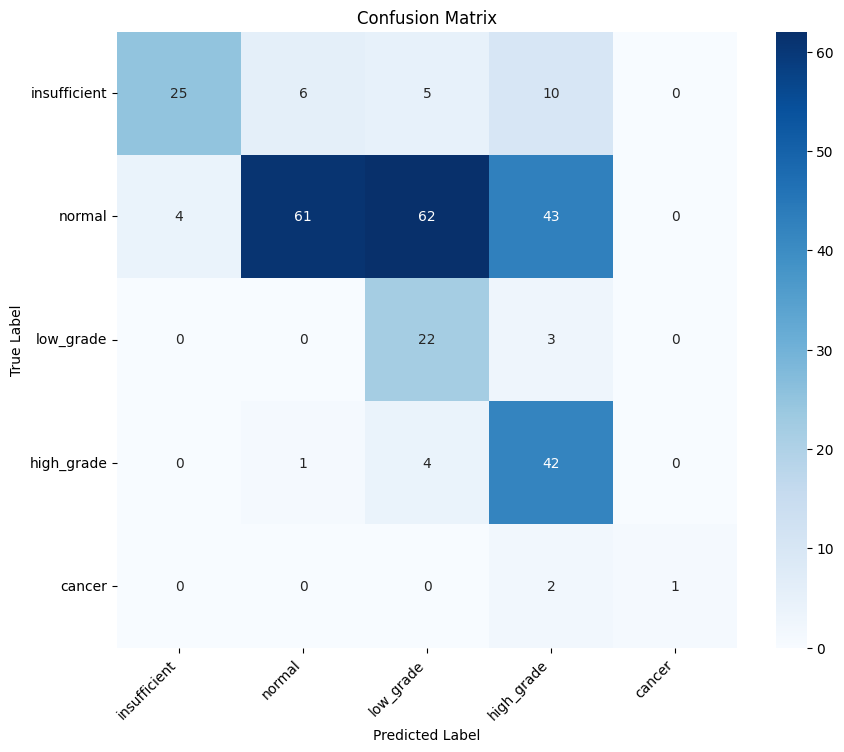

In [52]:
cm(patient_lvl.label, patient_lvl.pred, class_labels)